# Product Stockout Analysis

## Introduction
This project aims to analyze product data from ASOS to identify potential lost revenue due to product stockouts and to understand brand performance in relation to pricing and stock availability. By examining product descriptions, pricing, and stock status, we can uncover insights into product management and revenue optimization.

## Data Source
The analysis uses the `products_asos.csv` dataset, which contains information about various products, including their URLs, names, sizes, categories, prices, colors, SKUs, descriptions, and images.

## Analysis Steps
1.  **Data Loading and Initial Inspection**: The `products_asos.csv` file was loaded into a pandas DataFrame. Initial checks were performed to understand the data's structure and identify missing values.
2.  **Data Cleaning**: Missing values were inspected, and rows with missing 'price' data were dropped. The 'price' column was converted to a numeric type, coercing errors.
3.  **Brand Extraction**: Product descriptions, which often contain brand information (e.g., 'by BrandName'), were used to extract a raw brand name. A `get_brand` function was created for this purpose. A `brand_map` was then applied to standardize some brand names, and only brands with more than 5 products were kept for further analysis.
4.  **Stockout Calculation**: A `calculate_phantom_revenue` function was defined to parse the 'size' string, count the number of 'Out of stock' items for each product, and calculate a stockout rate. This was used to determine the number of stockouts and the overall stockout rate per product.
5.  **Lost Revenue Calculation**: The 'lost_revenue' for each product was calculated by multiplying its 'price' by the 'Stockout_count'.
6.  **Brand Strategy Analysis**: Brands were grouped to calculate their average price, average stockout rate, total lost revenue, and product count. This aggregated data was used to create a scatter plot.

## Key Findings
The scatter plot for Brand Strategy Analysis visualizes the relationship between average price, average stockout rate, and total lost revenue for different brands.

*   **High-Impact Brands**: Brands with an average price above 40 and an average stockout rate above 0.4 were highlighted as 'winner' brands. These brands, specifically **Mango**, **Naked**, **Pull&BearThrow**, **TopshopLove**, and **VilaAll**, represent products with significant lost revenue potential due to stockouts, indicating high demand for these more expensive, frequently out-of-stock items.
*   **Opportunity for Optimization**: The analysis suggests that focusing on improving inventory management for these 'winner' brands could lead to substantial revenue recovery.

## Tools and Libraries Used
*   `pandas` for data manipulation and analysis.
*   `matplotlib.pyplot` for plotting.
*   `seaborn` for enhanced data visualizations.
*   `numpy` for numerical operations (though not explicitly used in the final plot, it's typically imported with these libraries).


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('C:\\Users\\John\\Downloads\\products_asos.csv', on_bad_lines='skip')
print(df.head)

<bound method NDFrame.head of                                                      url  \
0      https://www.asos.com/stradivarius/stradivarius...   
1      https://www.asos.com/stradivarius/stradivarius...   
2      https://www.asos.com/asos-design/asos-design-l...   
3      https://www.asos.com/new-look/new-look-trench-...   
4      https://www.asos.com/stradivarius/stradivarius...   
...                                                  ...   
30840  https://www.asos.com/urban-revivo/urban-revivo...   
30841  https://www.asos.com/asos-design/asos-design-l...   
30842  https://www.asos.com/asyou/asyou-layered-t-shi...   
30843  https://www.asos.com/miss-selfridge/miss-selfr...   
30844  https://www.asos.com/other-stories/other-stori...   

                                                    name  \
0                          New Look trench coat in camel   
1                          New Look trench coat in camel   
2                          New Look trench coat in camel   
3        

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30845 entries, 0 to 30844
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          30827 non-null  object 
 1   name         30827 non-null  object 
 2   size         30827 non-null  object 
 3   category     30827 non-null  object 
 4   price        30827 non-null  object 
 5   color        30827 non-null  object 
 6   sku          30827 non-null  float64
 7   description  30827 non-null  object 
 8   images       30827 non-null  object 
dtypes: float64(1), object(8)
memory usage: 2.1+ MB


In [16]:
# cleaning the price column
df["price"] = pd.to_numeric(df["price"], errors='coerce')
df = df.dropna(subset=["price"])
print(f"rows loaded: {len(df)}")
df.head()

rows loaded: 18378


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [18]:
df["description"] = df["description"].astype(str)

In [20]:
def get_brand(text):
  if 'by ' in text:
    try:
      return text.split("by ")[1].split(' ')[0]
    except:
      return "Unknown"
  else:
    return "Unkown"
df["brand_raw"] = df["description"].apply(get_brand)
df.head()

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket


In [22]:
brand_map = {
    "New": "New Look",
    "River": "River Island",
    "Miss": "Miss Selfridge",
    "TopshopWelcome": "Topshop"
}
df["brand"] = df["brand_raw"].map(brand_map).fillna(df["brand_raw"])
brand_counts = df["brand"].value_counts()
valid_brands = brand_counts[brand_counts > 5]
df_clean = df[df["brand"].isin(valid_brands.index)].copy()
print(df_clean["brand"].value_counts().head())

brand
ASOS              4844
Topshop           1017
New Look           511
River Island       467
Miss Selfridge     429
Name: count, dtype: int64


In [24]:
def calculate_phantom_revenue(size_str):
    if not isinstance(size_str, str):
        return 0, 0.0

    # split "UK 6, UK 8 - out of stock" into list
    sizes = size_str.split(',')
    total_sizes = len(sizes)

    # count how many items are out of stock
    out_of_stock_count = size_str.count('Out of stock')

    # Calculate rate (0.0-1.0)
    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0
    return out_of_stock_count, rate

metrics = df_clean["size"].apply(lambda x: calculate_phantom_revenue(x))

df_clean["Stockout_count"] = [x[0] for x in metrics]
df_clean["Stockout_rate"] = [x[1] for x in metrics]

df_clean["lost_revenue"] = df_clean["price"] * df_clean["Stockout_count"]

cols = ["brand", "name", "price", "Stockout_count", "lost_revenue"]
print(df_clean.sort_values(by="lost_revenue", ascending=False).head(5)[cols])

         brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stockout_count  lost_revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


C:\Users\John\AppData\Local\Temp\ipykernel_14344\4049551936.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


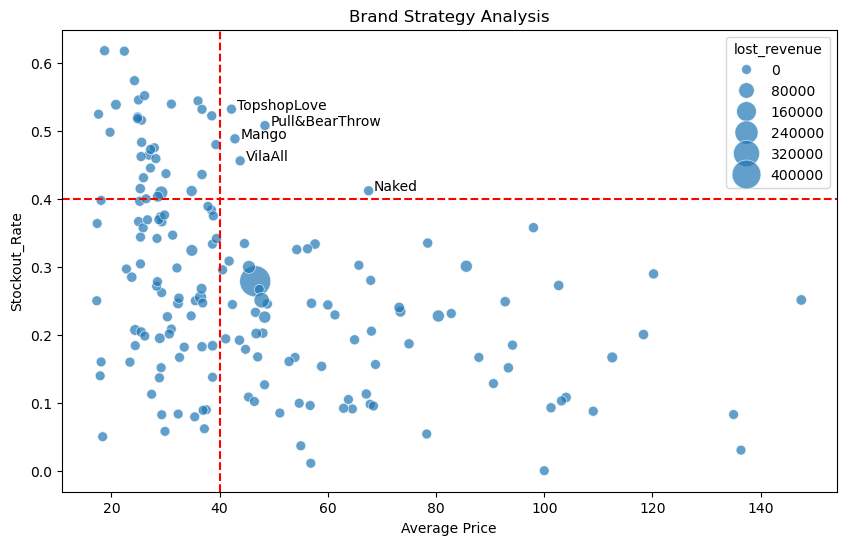

In [26]:
brand_strategy = df_clean.groupby("brand").agg({
    "price": "mean",
    "Stockout_rate": "mean",
    "lost_revenue": "sum",
    "name": "count"
}).reset_index()
brand_strategy = brand_strategy[brand_strategy["name"] > 10]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=brand_strategy,
    x = "price",
    y = "Stockout_rate",
    size = "lost_revenue",
    sizes = (50, 500),
    alpha = 0.7,
    palette = 'viridis'
)

winners = brand_strategy[(brand_strategy["price"] > 40) &
(brand_strategy["Stockout_rate"] > 0.4)]

for i in range(len(winners)):
    plt.text(
        winners.iloc[i]["price"] + 1,
        winners.iloc[i]["Stockout_rate"],
        winners.iloc[i]["brand"]
    )
plt.title("Brand Strategy Analysis")
plt.xlabel("Average Price")
plt.ylabel("Stockout_Rate")
plt.axvline(x=40, color="red", linestyle="--")
plt.axhline(y=0.4, color="red", linestyle="--")
plt.show()